In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%matplotlib inline

# Import data

In [4]:
bands = [4, 5, 6, 7]
num_bands = len(bands)


all_bands    = ["Band 4 nterms2",  "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]

bands_naming = ['Band4_nterms2',   "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4',          "Band 5",      'Band 6', 'Band 7']

band_to_index = {band: i for i, band in enumerate(all_bands)}

wavelengths = [lambda_mm[band] for band in bands]
lambda_bands_cm = mm_to_cm(wavelengths)
print(lambda_bands_cm)

band_colors = [alma_band_colors[band] for band in bands]

[0.21  0.15  0.13  0.087]


In [5]:
f_value = 1 


prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

band_prefix = {
    4: 'BAND4/',
    5: 'BAND5/',
    6: 'BAND6/',
    7: 'BAND7/',
}


file_name = 'dsharp_results_ff_1.00_smoothed_extrapol.npz'

In [6]:
# Make an array to store the data
data = {}

for band, wav in zip(bands, wavelengths):

    filename = prefix + band_prefix[band] + file_name
    d = np.load(filename)

    data[band]= do_things(d)

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.8e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 3.7e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 8.7e+03%: above error tolerance
  warnings.warn(


In [8]:
# POLF_avg = []

# for band in bands:
#     if band == 'Band 4':
#         path = constants.band4_data_folder_path + "constants_BAND4.csv"
#     elif band == 'Band 4 nterms2':
#         path = constants.band4_nterms2_data_folder_path + "constants_BAND4_nterms2.csv"
#     elif band == 'Band 5':
#         path = constants.band5_data_folder_path + "constants_BAND5.csv"
#     elif band == 'Band 6':
#         path = constants.band6_data_folder_path + "constants_BAND6.csv"
#     elif band == 'Band 7 nterms2':
#         path = constants.band7_nterms2_data_folder_path + "constants_BAND7_nterms2.csv"
#     else:
#         raise ValueError("Only 'Band 4', 'Band 4 nterms2', 'Band 5', 'Band 6', and 'Band 7 nterms2' are supported.")
    
#     print(rf"Now on {band}")
#     df = pd.read_csv(path)
#     print("Columns:", df.columns.tolist())
    
# #     POLF_avg.append(df["POLF_avg"].values[0] * 100)

# Figure 1 — Abs/Sca opacities vs wavelength

In [9]:
# This one doesnt work

# Figure 2 — Polarization vs scattering angle

In [10]:
# This one also doesnt work

# Figure 3 — P vs a_max (at θ = 90°)

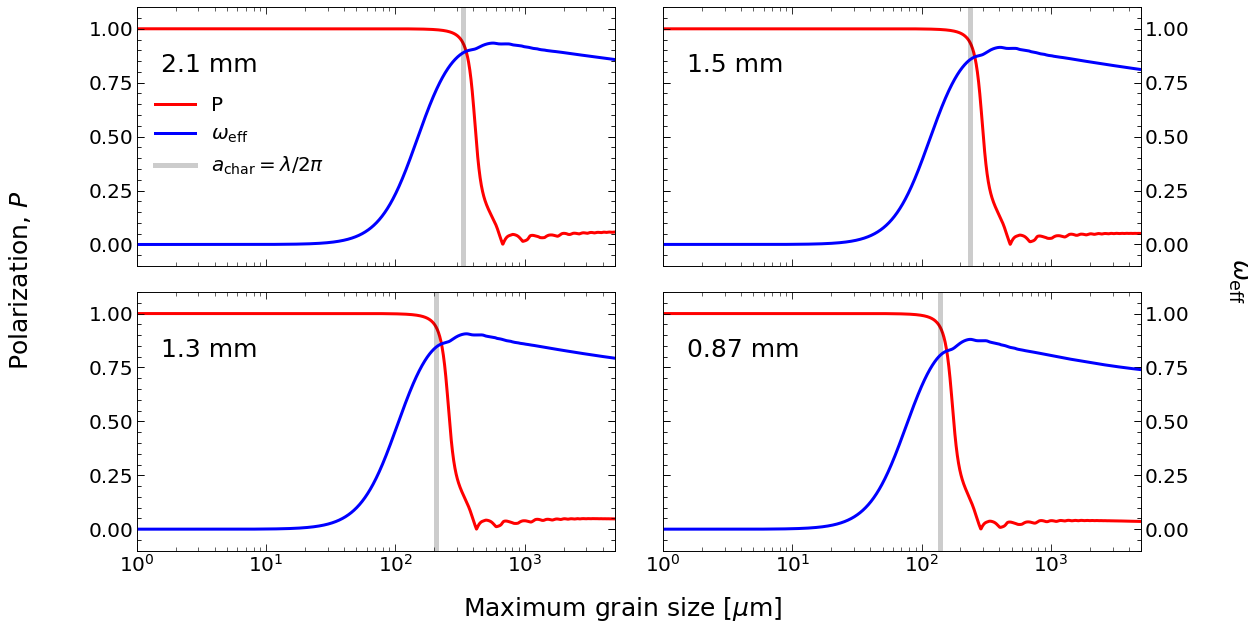

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex = True, sharey = True)
axes = axes.flatten()

ax2_list = []  # store twin axes

for j, ax in enumerate(axes):
    band_data = data[bands[j]]

    # Create twin axis
    ax2 = ax.twinx()
    ax2_list.append(ax2)

    # Plot P
    line_P, = ax.plot(
        cm_to_micron(band_data['a']),
        band_data['P'],
        color='red',
        label='P',
        lw=3
    )

    # Plot omega
    line_omega, = ax2.plot(
        cm_to_micron(band_data['a']),
        band_data['omega_eff'],
        color='blue',
        label = r'$\omega_{\mathrm{eff}}$',
        lw=3
    )

    # Labels
#     if j in (2, 3):
#         ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
#     if j in (0, 2):
#         ax.set_ylabel('P', fontsize=axis_label_fs)

#     if j in (1, 3):
#         ax2.set_ylabel(r'$\omega_{\mathrm{eff}}$', fontsize=axis_label_fs)

    # Log x-axis
    ax.set_xscale('log')
    add_min_major_ticks(ax)
    add_min_major_ticks(ax2)
    
    # Add the characteristic egtain size
    
    a_char_micron = cm_to_micron(lambda_bands_cm[j]/ (2 * np.pi))
    char_line = ax.axvline(a_char_micron, color = 'black', alpha = 0.2, lw = 5, 
                           label=r'$a_{\mathrm{char}} = \lambda / 2\pi$')
    #print(rf'lambda = {lambda_bands_cm[j]}, a_char_micron = {a_char_micron}')

    # Limits
    ax.set_ylim(-0.1, 1.1)
    ax2.set_ylim(-0.1, 1.1)
    ax.set_xlim(1, max(cm_to_micron(band_data['a'])))

    # Title text
    ax.text(
        0.05, 0.75,
        f"{constants.lambda_mm[fig3_bands_grid[j]]} mm",
        transform=ax.transAxes,
        fontsize=25
    )

    # Ticks (both axes)
    for a in [ax, ax2]:
        a.minorticks_on()
        a.tick_params(axis="x", which="minor", direction="in", length=4)
        a.tick_params(axis="y", which="minor", direction="in", length=4)

        a.tick_params(axis="x", which="major", direction="in", length=7, labelsize=axis_num_fs)
        a.tick_params(axis="y", which="major", direction="in", length=7, labelsize=axis_num_fs)
        
    if j in (0, 2):
        ax2.tick_params(axis='y', which='both', labelright=False)

    # Legend (per subplot)
    if j == 0:
        ax.legend(handles=[line_P, line_omega, char_line],
                  fontsize=20,
                  loc='center left',
                  frameon = False)
        


fig.supxlabel(
    'Maximum grain size [$\mu$m]',
    fontsize = 25,
    y = 0.025
)
    
    
fig.supylabel(
    r"Polarization, $P$",
    fontsize = 25,
    x = 0.025
)


fig.text(
    0.975, 0.5,
    r"$\omega_{\mathrm{eff}}$",
    fontsize=25,
    rotation= 270,
    ha='center',
    va='center'
)
  
    
# Spacing
fig.subplots_adjust(wspace=0.1, hspace=0.1)
    
plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "P_vs_w_eff_vs_grainsize_grid_smooth.pdf", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

## Figure 4

In [ ]:
top_label = []
bottom_label = []

for band in bands:
    top = f"{lambda_mm[band]} mm"
    bottom = f"(Band {band})"
    
    top_label.append(top)
    bottom_label.append(bottom)

At Band Band 4, the highest Pw value is 0.8409565725543404
At this Pw value, the a_max value is 307.88 micron
a_char_micron =  334.23 micron
 
At Band Band 5, the highest Pw value is 0.8085144967467731
At this Pw value, the a_max value is 223.71 micron
a_char_micron =  238.73 micron
 
At Band Band 6, the highest Pw value is 0.7960845525459214
At this Pw value, the a_max value is 196.46 micron
a_char_micron =  206.90 micron
 
At Band Band 7, the highest Pw value is 0.7578394407965862
At this Pw value, the a_max value is 134.50 micron
a_char_micron =  138.46 micron
 


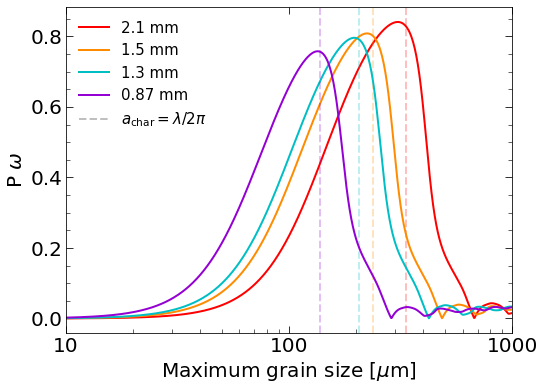

In [23]:
# mm

# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))
#                [B4,  B6,   B7]
# P_scale_factor = [1.15, 1.68, 1.2]

for i, band in enumerate(bands):
    
    band_data = data[band]
        
    ax.plot(cm_to_micron(band_data['a']),
            band_data['P_omega_eff'],
            color = alma_band_colors[band],
            ls = '-',
            lw = 2, 
            label = f'{cm_to_mm(lambda_bands_cm[i]):.1f} mm' if i != 3 else f'{cm_to_mm(lambda_bands_cm[i]):.2f} mm')
    
    
    a_char_micron = cm_to_micron(lambda_bands_cm[i]/ (2 * np.pi))
    ax.axvline(a_char_micron, 
               color = alma_band_colors[band],
               alpha = 0.25, lw = 2, 
               ls = '--')
    
    
    # Find index of max Pw
    max_idx = np.argmax(band_data['P_omega_eff'])

    max_val =band_data['P_omega_eff'][max_idx]
    amax_at_max = cm_to_micron(band_data['a'][max_idx])

    print(f'At Band {bands_labels[i]}, the highest Pw value is {max_val}')
    print(f'At this Pw value, the a_max value is {amax_at_max:.2f} micron')
    print(f'a_char_micron =  {a_char_micron:.2f} micron')
    print(' ')


# Add axis labels
ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('P $\omega$', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True,   length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True,   right=True, length=7, labelsize=axis_num_fs)



# Make axes log if needed
ax.set_xscale('log')
# ax.set_yscale('log')

# Remove scientific notation from x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

# ---------------------------------------------------------------------------------
# ---------------------------------------------------------------------------------
# fs = 15
# x_offset = [2, 1, 1]

# for i in range(1):
#     y_loc = np.max(P_times_omega[:, i])
#     idx = np.argmax(P_times_omega[:, i])
#     x_loc = a_max_dist_micron[idx]

#     # Offset value can be tuned depending on your data scale
#     ax.text(x_loc * x_offset[i], y_loc + 0.1,  # top label slightly above peak
#             top_label[i],
#             color=band_colors[i],
#             fontsize=fs,
#             ha='center')

#     ax.text(x_loc * x_offset[i], y_loc + 0.01,  # bottom label at peak
#             bottom_label[i],
#             color=band_colors[i],
#             fontsize=fs,
#             ha='center')
 # ---------------------------------------------------------------------------------   
    
# Add horizontal lines of POLF_avg at each band if my own data
# for i in range(num_bands):
#     ax.axhline(POLF_avg[i], color = band_colors[i], ls = '--', lw = 3)

# ax.set_ylim(-0.1, 1.5)

ax.axvline(-100, 
       color = 'black',
       alpha = 0.25, lw = 2, 
       ls = '--',
       label=r'$a_{\mathrm{char}} = \lambda / 2\pi$')

ax.set_xlim(10, 1000)

ax.legend(fontsize = legend_text_fs, frameon = False)

# ax.axhline(0.8, color = 'black', ls = '--', lw = 3)



# plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "Pw_vs_grainsize_smooth.pdf", 
#             dpi=300, 
#             facecolor='white',
#             bbox_inches='tight') 